In [1]:
# ------------------------------------
# Save location for plots
# ------------------------------------
SAVE_DIR = './figures/pCAP'



# ------------------------------------
# Imports
# ------------------------------------
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter



# ------------------------------------
# Mathematical/logical functions
# ------------------------------------
def lin_comb(coeffs,vectors):
    psi = np.zeros(len(vectors[0]), dtype=complex)
    j = 0
    while j < len(vectors):
        psi += coeffs[j]*vectors[j]
        j+=1
    return psi

def local_density_from_psi(x,low,high,psi):
    low_idx = np.argsort((x-low)**2)[0]
    high_idx = np.argsort((x-high)**2)[0]
    return np.trapz(np.conj(psi[low_idx:high_idx])*psi[low_idx:high_idx],x[low_idx:high_idx])

1. We begin by specifying the 1D space, including the boundaries (xmax, xmin) and the number of discrete points in space (N).  N must be large enough to converge the properties of the resonance. However, because the Hamiltonian diagonalizations will be performed in the basis of the discrete points of space, N must be small enough for these calculations to remain tractable.

In [2]:
# ------------------------------------
# Preparing 1D space
# ------------------------------------
N = 2000
xmax = 200
xmin = -200

dx = (xmax-xmin)/N
x = np.linspace(xmin,xmax,N)

2. We now prepare a potential energy surface that supports a metastable state (resonance). This potential features a well centered at zero. Dynamically, a particle placed in this well will tunnel out of the well over a finite period. However, we are interested in calculating the characteristic resonance energy and width of a particle in this system without using dynamics, instead treating the resonance as a stationary state with complex energy. This will be accomplished using a non-Hermitian approach called the projected complex absorbing potential (pCAP) method. Some of the steps in this implementation of pCAP are notably different from how it is typically implemented in electronic structure calculations due to the simplicity of the system and the relatively large size and near-completeness of the 1D space basis used here. The steps that differ significantly from a typical electronic structure implementation will be identified when we come to them.

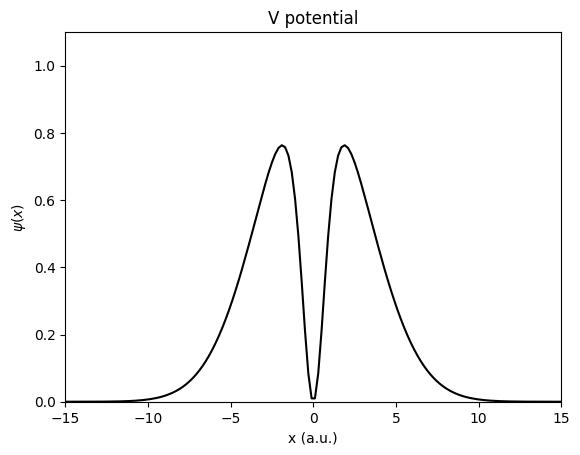

<Figure size 640x480 with 0 Axes>

In [3]:
# ------------------------------------
# Preparing potential surface
# ------------------------------------
def V(x):
    # A system supporting a single metastable state
    V0 = 1
    alpha = 0.05
    beta = 1
    return (1-V0/np.cosh(beta*x)**2)*np.exp(-alpha*x**2)

V_potential = V(x)



# ------------------------------------
# Plotting potential surface
# ------------------------------------
plt.xlabel('x (a.u.)')
plt.ylabel(r'$\psi(x)$')
plt.ylim(bottom=0,top=1.1)
plt.xlim(left=-15.0,right=15.0)
plt.plot(x,V_potential,color='black')
plt.title('V potential')
plt.savefig(os.path.join(SAVE_DIR,'V_potential.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

3. [Runtime ~ 10 sec] We now construct and diagonalize the system Hamiltonian. This produces a set of discretized continuum eigenstates, which are plotted in light blue (and notable eigenstates in darker blue). One can observe that some of the eigenstates near 0.5 au of energy have significant amplitude inside the well. This is indicative of a resonance at approximately 0.5 au of energy. The system Hamiltonian will be referred to as the zero-order Hamiltonian going forward because we will be perturbing this system with an imaginary absorbing potential in the subsequent steps.

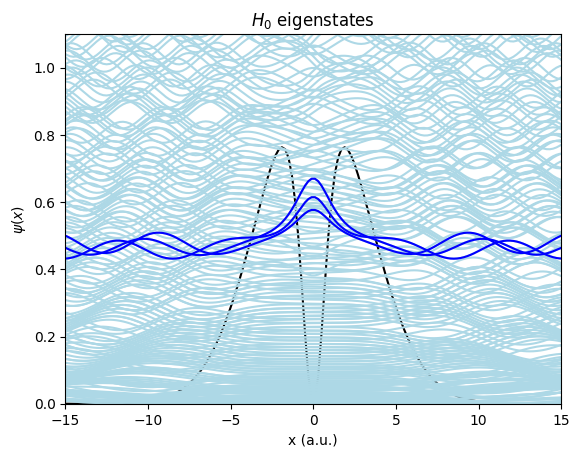

<Figure size 640x480 with 0 Axes>

In [4]:
# ------------------------------------
# Constructing zero-order Hamiltonian
# ------------------------------------
H = np.zeros((N,N))

for i in range(N):
  for j in range(N):
    if i == j+1:
      H[i,j] = -1/(2*dx**2)
    if i == j:
      H[i,j] = 1/(dx**2) + V_potential[i]
    if i == j-1:
      H[i,j] = -1/(2*dx**2)



# ------------------------------------
# Diagonalizing zero-order Hamiltonian
# ------------------------------------
w,v = np.linalg.eig(H)

sorter = np.argsort(w)
w = w[sorter]
v = v.T
v = v[sorter]



# ------------------------------------
# Plotting eigenstates
# ------------------------------------
plt.xlabel('x (a.u.)')
plt.ylabel(r'$\psi(x)$')
plt.ylim(bottom=0,top=1.1)
plt.xlim(left=-15.0,right=15.0)
plt.plot(x,V_potential,color='black')
i = 0
while i < 200:
  plt.plot(x,-v[i]+w[i],color='lightblue')
  i+=1
plt.plot(x,-v[118]+w[118],color='blue')
plt.plot(x,-v[120]+w[120],color='blue')
plt.plot(x,-v[122]+w[122],color='blue')
plt.title(r'$H_{0}$ eigenstates')
plt.savefig(os.path.join(SAVE_DIR,'H0_eigenstates.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

4. [Runtime ~ 25 sec] We now prepare the CAP Hamiltonian in the basis of the zero-order eigenstates calculated above. This CAP Hamiltonian is the zero-order system Hamiltonian (which is diagonal in the basis of its own eigenstates) with a perturbation added. This perturbation is imaginary and is composed of an absorbing potential (-W) and a strength parameter (eta). The absorbing potential is zero in the region of the well (x = {-5,5}) and increases with x^2 outside it. The strength parameter scales this absorbing potential. Note that eta*W is plotted in the following figures, which is easy to visualize but is missing the negative sign that makes it an absorbing potential.

This is where the first significant deviation from a typical electronic structure implementation is observed: In a typical electronic structure implementation of the pCAP method, a so-called "eta-trajectory" is used to determine an optimal value for the eta parameter. Here, an eta-trajectory is not necessary for selecting an accurate value for the eta parameter (and is in fact unreasonably expensive for this simple model calculation) because of the relatively large size and high density of this zero-order eigenstate basis. All reasonable values for the eta parameter (where the absorbing potential does not encroach on the well but approaches very large values within the space) will yield highly accurate results in this calculation.

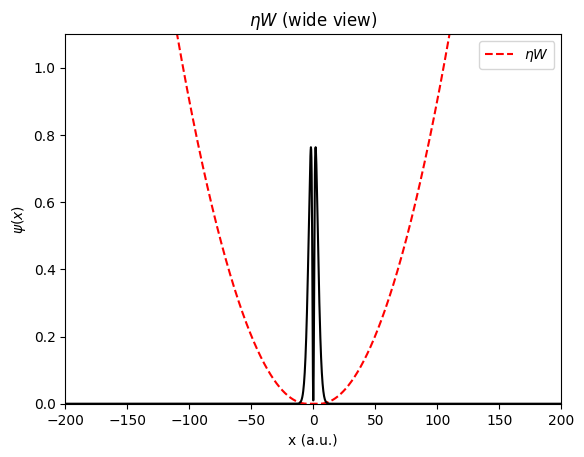

<Figure size 640x480 with 0 Axes>

In [5]:
# ------------------------------------
# Preparing CAP functional form
# ------------------------------------
def W(x):
    x_onset = 5
    return np.piecewise(x, [np.abs(x) < x_onset, np.abs(x) >= x_onset], [0, lambda x: (np.abs(x) - x_onset)**2])

W_potential = W(x)



# ------------------------------------
# Preparing CAP Hamiltonian in zero-order eigenstate basis
# ------------------------------------
eta = 0.0001

H0 = np.zeros((N,N),dtype=complex)
W_mat = np.zeros((N,N),dtype=complex)

for i in range(N):
    H0[i,i] = w[i]

for i in range(N):
  for j in range(N):
      W_mat[i,j] = np.trapz(v[i]*W_potential*v[j])

Hcap = H0 - 1.0j*eta*W_mat



plt.xlabel('x (a.u.)')
plt.ylabel(r'$\psi(x)$')
plt.ylim(bottom=0,top=1.1)
plt.xlim(left=xmin,right=xmax)
plt.plot(x,eta*W_potential,'--r',label=r'$\eta W$')
plt.plot(x,V_potential,color='black')
plt.title(r'$\eta W$ (wide view)')
plt.legend()
plt.savefig(os.path.join(SAVE_DIR,'etaW_wide.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

5. [Runtime ~ 30 sec] We now diagonalize the CAP Hamiltonian and identify the resonance eigenpair. This is a non-Hermitian eigenproblem because the CAP Hamiltonian is complex, which means that all eigenvalues and eigenvectors are generally complex, and the left and right eigenvectors will generally be different from one another (we only calculate the right eigenvectors). We can identify the resonance eigenpair by sorting the eigenpairs with respect to the particle density inside the well, as we would expect that the resonance eigenstate would have high particle density inside the well. Indeed, the representative resonance eigenstate in this calculation has the highest particle density inside the well, which is visually apparent from the final figure where most of the eigenstates are plotted in salmon and the resonance eigenstate is plotted in blue. The resonance energy is the real component of the associated eigenvalue, and the width is the imaginary component of the associated eigenvalue multiplied by a factor of -2. The results of this calculation align almost exactly with the results of a dynamics-based approach (see "1DResonance_dynamics.ipynb").

This is where the second significant deviation from a typical electronic structure implementation is observed: In a typical electronic structure implementation of the pCAP method, practitioners must make an informed guess as to which wavefunction represents the resonance. This guess is often guided by the eigenvalues (final energy and width values), wavefunction characters (natural orbital character/occupation), and eta trajectories (looking for stationary points) of the various eigenstates. Wavefunction density in the physical space of the well is not the most reliable or natural means of identifying a resonance in a chemical system. In this simple model system, however, sorting based on wavefunction density in the well is an easy and accurate approach.

Resonance energy = 0.46454174580828045
Resonance width = 0.00923683829750666


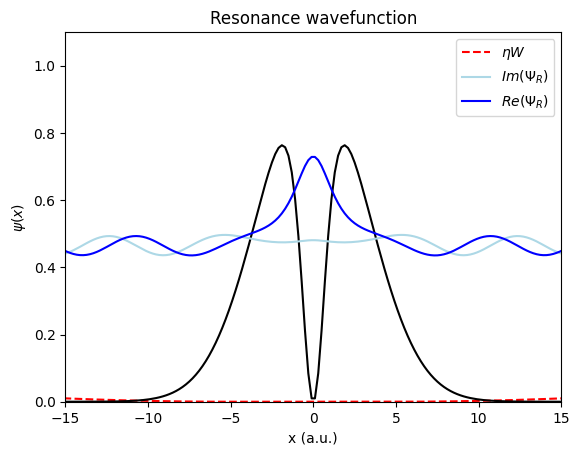

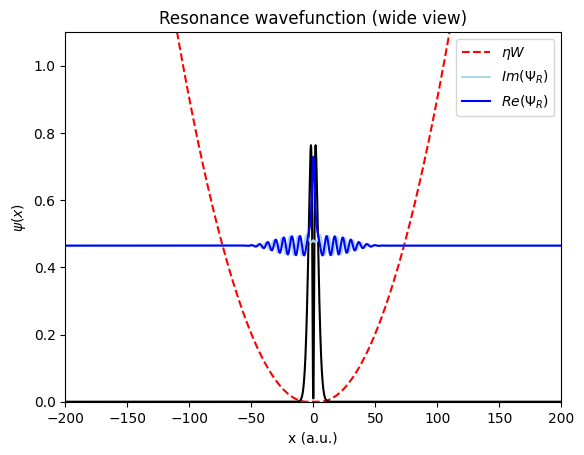

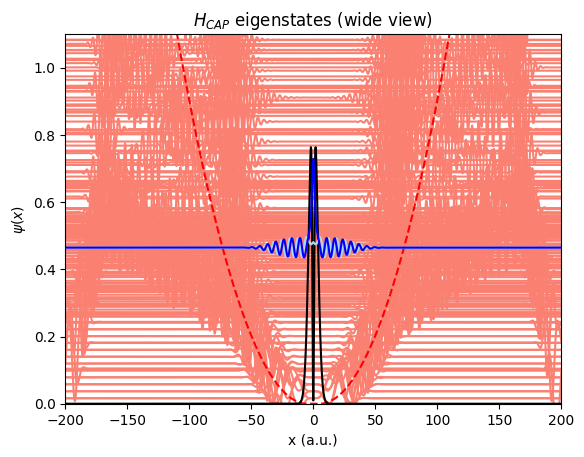

<Figure size 640x480 with 0 Axes>

In [6]:
# ------------------------------------
# Diagonalizing CAP Hamiltonian in zero-order eigenstate basis
# ------------------------------------
Rw,Rv = np.linalg.eig(Hcap)

sorter = np.argsort(np.real(Rw))
Rw = Rw[sorter]
Rv = Rv.T
Rv = Rv[sorter]



# ------------------------------------
# Calculating CAP Hamiltonian eigenstates in 1D space
# ------------------------------------
psi_Rv = []
for coeffs in Rv:
    psi_Rv.append(lin_comb(coeffs,v))



# ------------------------------------
# Sorting by particle density in the well to locate resonance state: wavefunction, energy, and width
# ------------------------------------
well_dens = []
for psi_i in psi_Rv:
    well_dens.append(local_density_from_psi(x,-1,1,psi_i))
dens_sorter = np.argsort(well_dens)[::-1]

resonance_psi = psi_Rv[dens_sorter[0]]  #resonance wavefunction
ER = np.real(Rw[dens_sorter[0]])  #resonance energy
Gamma = -2*np.imag(Rw[dens_sorter[0]])  #resonance width

print("Resonance energy =",ER)
print("Resonance width =",Gamma)



# ------------------------------------
# Plotting resonance
# ------------------------------------
plt.xlabel('x (a.u.)')
plt.ylabel(r'$\psi(x)$')
plt.ylim(bottom=0,top=1.1)
plt.xlim(left=-15.0,right=15.0)
plt.plot(x,eta*W_potential,'--r',label=r'$\eta W$')
plt.plot(x,V_potential,color='black')
plt.plot(x,-np.imag(resonance_psi)+ER,color='lightblue',label=r'$Im(\Psi_{R})$')
plt.plot(x,-np.real(resonance_psi)+ER,color='blue',label=r'$Re(\Psi_{R})$')
plt.title('Resonance wavefunction')
plt.legend()
plt.savefig(os.path.join(SAVE_DIR,'resonance.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

plt.xlabel('x (a.u.)')
plt.ylabel(r'$\psi(x)$')
plt.ylim(bottom=0,top=1.1)
plt.xlim(left=xmin,right=xmax)
plt.plot(x,eta*W_potential,'--r',label=r'$\eta W$')
plt.plot(x,V_potential,color='black')
plt.plot(x,-np.imag(resonance_psi)+ER,color='lightblue',label=r'$Im(\Psi_{R})$')
plt.plot(x,-np.real(resonance_psi)+ER,color='blue',label=r'$Re(\Psi_{R})$')
plt.title('Resonance wavefunction (wide view)')
plt.legend()
plt.savefig(os.path.join(SAVE_DIR,'resonance_wide.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

plt.xlabel('x (a.u.)')
plt.ylabel(r'$\psi(x)$')
plt.ylim(bottom=0,top=1.1)
plt.xlim(left=xmin,right=xmax)
i = 0
while i < len(psi_Rv):
    plt.plot(x,np.real(psi_Rv[i])+np.real(Rw[i]),color='salmon')
    i+=1
plt.plot(x,eta*W_potential,'--r')
plt.plot(x,V_potential,color='black')
plt.plot(x,-np.imag(resonance_psi)+ER,color='lightblue')
plt.plot(x,-np.real(resonance_psi)+ER,color='blue')
plt.title(r'$H_{CAP}$ eigenstates (wide view)')
plt.savefig(os.path.join(SAVE_DIR,'Hcap_eigenstates.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()